In [2]:
#import libs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
#load dataset
df = pd.read_csv("C:/Users/Dheeraj Sharma/Downloads/housing.csv/housing.csv")

print("Shape:", df.shape)

df.head()

Shape: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [5]:
# info
print(df.info())

df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB
None


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [6]:
print(df.isnull().sum())

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [7]:
#handling missing values
df["total_bedrooms"] = df["total_bedrooms"].fillna(
    df["total_bedrooms"].median()
)

print(df.isnull().sum())

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


In [9]:
#target is median_house_value
X = df.drop("median_house_value", axis=1)

y = df["median_house_value"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (20640, 9)
y shape: (20640,)


In [11]:
#one hot encoding for categorical value:
X = pd.get_dummies(
    X,
    columns=["ocean_proximity"],
    dtype=int
)

print(X.head())

print("\nNew shape:", X.shape)

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  ocean_proximity_<1H OCEAN  \
0       322.0       126.0         8.3252                          0   
1      2401.0      1138.0         8.3014                          0   
2       496.0       177.0         7.2574                          0   
3       558.0       219.0         5.6431                          0   
4       565.0       259.0         3.8462                          0   

   ocean_proximity_INLAND  ocean_proximity_ISLAND  ocean_proximity_NEAR BAY  \
0                       0                  

In [12]:
X = X.values
y = y.values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (20640, 13)
y shape: (20640,)


In [13]:
#train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (16512, 13)
Testing data: (4128, 13)


In [14]:
#feature scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Training mean:")
print(X_train_scaled.mean(axis=0))

print("\nTraining standard deviation:")
print(X_train_scaled.std(axis=0))

Training mean:
[-3.87910056e-13  7.99652724e-14 -6.68608149e-17  2.31498175e-17
 -6.76542156e-17 -2.60880895e-18 -3.86749203e-17 -6.59266865e-15
 -1.08133114e-15  3.56532740e-16 -5.09135037e-16  2.23443142e-16
 -1.50523570e-15]

Training standard deviation:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [16]:
#add intercept column:
X_train_b = np.c_[
    np.ones((X_train_scaled.shape[0], 1)),
    X_train_scaled
]

X_test_b = np.c_[
    np.ones((X_test_scaled.shape[0], 1)),
    X_test_scaled
]

print("X_train_b:", X_train_b.shape)
print("X_test_b:", X_test_b.shape)

X_train_b: (16512, 14)
X_test_b: (4128, 14)


In [17]:
#normal equation
XTX = np.dot(
    X_train_b.T,
    X_train_b
)

XTX_inverse = np.linalg.pinv(XTX)

XTy = np.dot(
    X_train_b.T,
    y_train
)

theta_normal = np.dot(
    XTX_inverse,
    XTy
)

print("Theta:")
print(theta_normal)

Theta:
[207194.69373787 -53826.64801649 -54415.6961445   13889.86618856
 -13094.25116219  43068.18184187 -43403.43242732  18382.19632373
  75167.77476625   6424.35562855 -12492.68755954   2319.63426583
   2459.94570874   5435.0100562 ]


In [18]:
#predict normal equation:
y_pred_normal = np.dot(
    X_test_b,
    theta_normal
)

print("First 10 predictions:")
print(y_pred_normal[:10])

print("\nFirst 10 actual values:")
print(y_test[:10])

First 10 predictions:
[ 54055.44889898 124225.33893718 255489.37949166 268002.43156919
 262769.43481568 139606.3039556  290665.42391417 228264.87637529
 256506.78561005 407923.85843486]

First 10 actual values:
[ 47700.  45800. 500001. 218600. 278000. 158700. 198200. 157500. 340000.
 446600.]


In [19]:
#evaluate normal equation:
mse_normal = mean_squared_error(
    y_test,
    y_pred_normal
)

r2_normal = r2_score(
    y_test,
    y_pred_normal
)

print("Normal Equation")
print("----------------")
print("MSE:", mse_normal)
print("R²:", r2_normal)

Normal Equation
----------------
MSE: 4908476721.156612
R²: 0.6254240620553608


In [20]:
#gradient descent:
def gradient_descent(
    X,
    y,
    learning_rate=0.01,
    iterations=2000
):
    
    m = len(y)
    
    # Initialize theta
    theta = np.zeros(X.shape[1])
    
    loss_history = []
    
    for i in range(iterations):
        
        # Predictions
        predictions = np.dot(X, theta)
        
        # Error
        errors = predictions - y
        
        # Gradient
        gradient = np.dot(
            X.T,
            errors
        ) / m
        
        # Update theta
        theta = theta - learning_rate * gradient
        
        # Cost
        loss = np.sum(errors ** 2) / (2 * m)
        
        loss_history.append(loss)
    
    return theta, loss_history

In [21]:
#train GD
theta_gd, loss_history = gradient_descent(
    X_train_b,
    y_train,
    learning_rate=0.01,
    iterations=2000
)

print("Gradient Descent Theta:")
print(theta_gd)

Gradient Descent Theta:
[207194.69335172 -25379.25645729 -24620.23593102  14585.94771753
  -2471.54700002  26789.83538273 -40682.42951197  22148.27759599
  73427.05827649   8830.73605852 -19106.2985403    2601.33837847
   5025.84897587   8643.56913841]


In [22]:
#GD prediction:
y_pred_gd = np.dot(
    X_test_b,
    theta_gd
)

print("First 10 predictions:")
print(y_pred_gd[:10])

First 10 predictions:
[ 52780.14890203 112899.52945521 269152.92894675 270574.95468114
 254418.96727061 148556.75778341 286002.4074994  225648.2881535
 253815.89751275 408549.00758282]


In [23]:
#GD Evaluation:
mse_gd = mean_squared_error(
    y_test,
    y_pred_gd
)

r2_gd = r2_score(
    y_test,
    y_pred_gd
)

print("Gradient Descent")
print("----------------")
print("MSE:", mse_gd)
print("R²:", r2_gd)

Gradient Descent
----------------
MSE: 4912600336.885479
R²: 0.6251093804714174


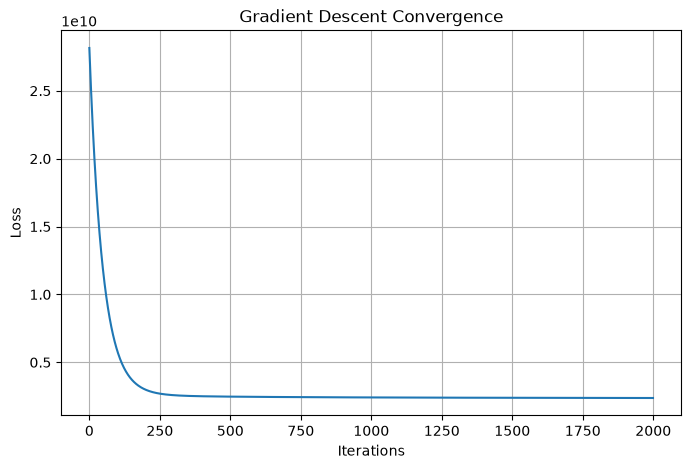

In [25]:
#GD loss graph:
plt.figure(figsize=(8, 5))

plt.plot(loss_history)

plt.xlabel("Iterations")
plt.ylabel("Loss")

plt.title("Gradient Descent Convergence")

plt.grid(True)

plt.show()

In [26]:
#scikit-learn Regression:
linear_model = LinearRegression()

linear_model.fit(
    X_train_scaled,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[-53826.65,-54415.7 , 13889.87,..., 2319.63, 2459.95, 5435.01]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.072e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(12)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](13,)","[254.47,205.96,164.88,..., 20.92, 15.46, 0. ]"


In [27]:
#Linear Regression predictions
y_pred_sklearn = linear_model.predict(
    X_test_scaled
)

print("First 10 predictions:")
print(y_pred_sklearn[:10])

First 10 predictions:
[ 54055.44889898 124225.33893718 255489.37949166 268002.43156919
 262769.43481568 139606.3039556  290665.42391417 228264.87637529
 256506.78561005 407923.85843486]


In [28]:
#evaluate linear regression
mse_sklearn = mean_squared_error(
    y_test,
    y_pred_sklearn
)

r2_sklearn = r2_score(
    y_test,
    y_pred_sklearn
)

print("Scikit-learn Linear Regression")
print("--------------------------------")
print("MSE:", mse_sklearn)
print("R²:", r2_sklearn)

Scikit-learn Linear Regression
--------------------------------
MSE: 4908476721.156616
R²: 0.6254240620553606


In [29]:
#ridge regression
ridge_model = Ridge(
    alpha=1.0
)

ridge_model.fit(
    X_train_scaled,
    y_train
)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' 

In [31]:
#Ridge prediction
y_pred_ridge = ridge_model.predict(
    X_test_scaled
)

print(y_pred_ridge[:10])

[ 54056.20083563 124196.25863221 255577.37617719 268015.65935969
 262733.89942385 139674.54385409 290630.32650869 228244.43916326
 256511.53753866 407909.39838904]


In [32]:
#evaluate ridge
mse_ridge = mean_squared_error(
    y_test,
    y_pred_ridge
)

r2_ridge = r2_score(
    y_test,
    y_pred_ridge
)

print("Ridge Regression")
print("----------------")
print("MSE:", mse_ridge)
print("R²:", r2_ridge)

Ridge Regression
----------------
MSE: 4908043808.254883
R²: 0.6254570985278605


In [33]:
#lasso reg
lasso_model = Lasso(
    alpha=0.01,
    max_iter=10000
)

lasso_model.fit(
    X_train_scaled,
    y_train
)

C:\Users\Dheeraj Sharma\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.441241e+12, tolerance: 2.207e+10
  model = cd_fast.enet_coordinate_descent(


,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.01
,"max_iter max_iter: int, default=1000The maximum number of iterations.",10000
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


In [34]:
#lasso prediction
y_pred_lasso = lasso_model.predict(
    X_test_scaled
)

print(y_pred_lasso[:10])

[ 54055.46690915 124225.27377785 255489.44544692 268002.4868647
 262769.34196868 139606.44248732 290665.35280277 228264.84611186
 256506.71471924 407923.81052375]


In [35]:
#evaluate lasso
mse_lasso = mean_squared_error(
    y_test,
    y_pred_lasso
)

r2_lasso = r2_score(
    y_test,
    y_pred_lasso
)

print("Lasso Regression")
print("----------------")
print("MSE:", mse_lasso)
print("R²:", r2_lasso)

Lasso Regression
----------------
MSE: 4908475937.144883
R²: 0.6254241218849059


In [37]:
#compare models
results = pd.DataFrame({
    "Model": [
        "Normal Equation",
        "Gradient Descent",
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression"
    ],
    
    "MSE": [
        mse_normal,
        mse_gd,
        mse_sklearn,
        mse_ridge,
        mse_lasso
    ],
    
    "R² Score": [
        r2_normal,
        r2_gd,
        r2_sklearn,
        r2_ridge,
        r2_lasso
    ]
})

results

,Model,MSE,R² Score
0,Normal Equation,4.908477e+09,0.625424
1,Gradient Descent,4.912600e+09,0.625109
2,Linear Regression,4.908477e+09,0.625424
3,Ridge Regression,4.908044e+09,0.625457
4,Lasso Regression,4.908476e+09,0.625424


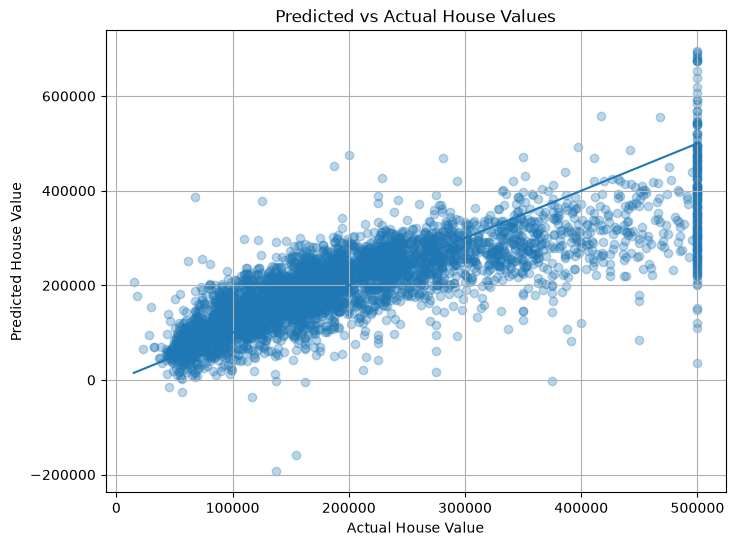

In [38]:
#predicted vs actual
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_sklearn,
    alpha=0.3
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual House Value")

plt.ylabel("Predicted House Value")

plt.title("Predicted vs Actual House Values")

plt.grid(True)

plt.show()

In [39]:
#compare coefficients:
feature_names = [
    "longitude",
    "latitude",
    "housing_median_age",
    "total_rooms",
    "total_bedrooms",
    "population",
    "households",
    "median_income",
    "ocean_proximity_<1H OCEAN",
    "ocean_proximity_INLAND",
    "ocean_proximity_ISLAND",
    "ocean_proximity_NEAR BAY",
    "ocean_proximity_NEAR OCEAN"
]

coefficients = pd.DataFrame({
    "Feature": feature_names,
    "Linear Regression": linear_model.coef_,
    "Ridge": ridge_model.coef_,
    "Lasso": lasso_model.coef_
})

coefficients

,Feature,Linear Regression,Ridge,Lasso
0,longitude,-53826.648016,-53712.509747,-53826.391585
1,latitude,-54415.696144,-54296.817789,-54415.427142
2,housing_median_age,13889.866189,13890.472975,13889.864983
3,total_rooms,-13094.251162,-13058.258308,-13094.047434
4,total_bedrooms,43068.181842,42978.146964,43067.974520
5,population,-43403.432427,-43390.111142,-43403.360426
6,households,18382.196324,18425.364025,18382.138689
7,median_income,75167.774766,75157.472154,75167.727814
8,ocean_proximity_<1H OCEAN,6424.355629,6433.287647,8211.488961
9,ocean_proximity_INLAND,-12492.687560,-12518.130263,-10819.955603


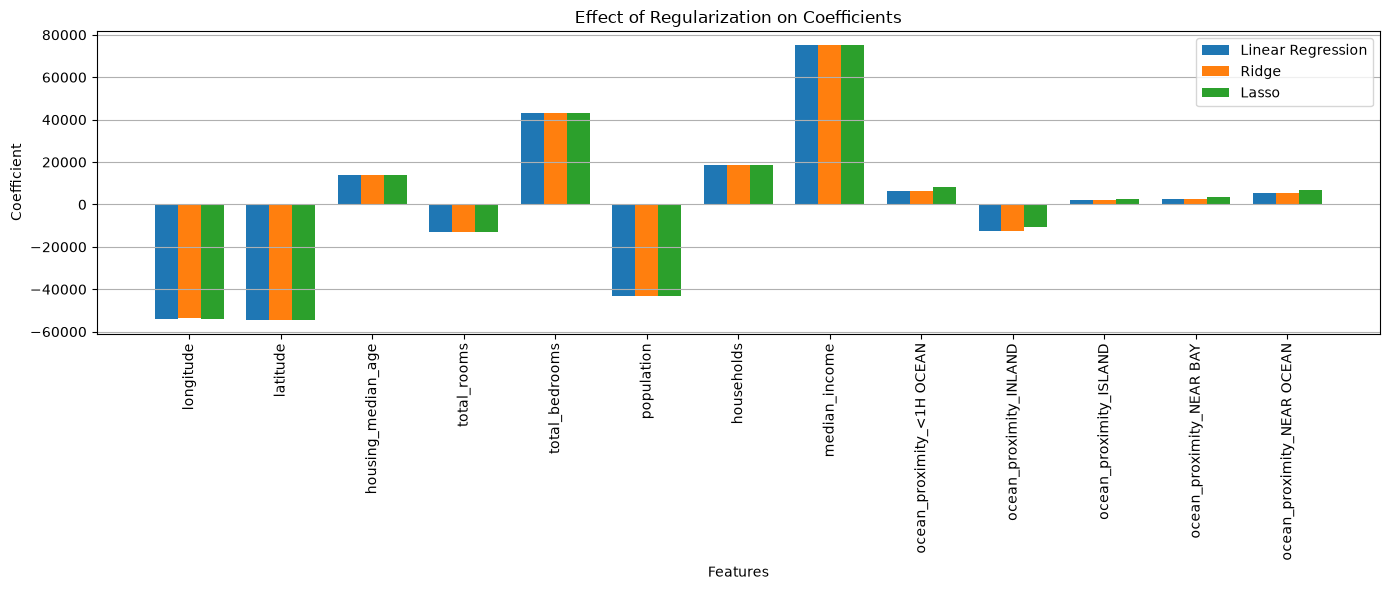

In [40]:
#plot coefficients:
x = np.arange(len(feature_names))

width = 0.25

plt.figure(figsize=(14, 6))

plt.bar(
    x - width,
    linear_model.coef_,
    width,
    label="Linear Regression"
)

plt.bar(
    x,
    ridge_model.coef_,
    width,
    label="Ridge"
)

plt.bar(
    x + width,
    lasso_model.coef_,
    width,
    label="Lasso"
)

plt.xticks(
    x,
    feature_names,
    rotation=90
)

plt.xlabel("Features")

plt.ylabel("Coefficient")

plt.title("Effect of Regularization on Coefficients")

plt.legend()

plt.grid(axis="y")

plt.tight_layout()

plt.show()

In [41]:
#check lasso feature selection:
print("Lasso coefficients:\n")

for feature, coefficient in zip(
    feature_names,
    lasso_model.coef_
):
    
    print(
        f"{feature}: {coefficient:.6f}"
    )

Lasso coefficients:

longitude: -53826.391585
latitude: -54415.427142
housing_median_age: 13889.864983
total_rooms: -13094.047434
total_bedrooms: 43067.974520
population: -43403.360426
households: 18382.138689
median_income: 75167.727814
ocean_proximity_<1H OCEAN: 8211.488961
ocean_proximity_INLAND: -10819.955603
ocean_proximity_ISLAND: 2375.595170
ocean_proximity_NEAR BAY: 3595.387479
ocean_proximity_NEAR OCEAN: 6629.831523


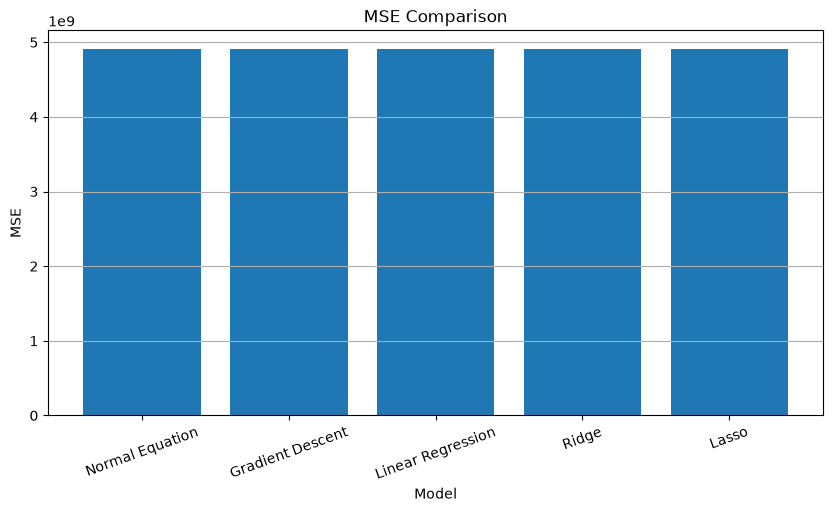

In [42]:
#MSE comparison graph:
models = [
    "Normal Equation",
    "Gradient Descent",
    "Linear Regression",
    "Ridge",
    "Lasso"
]

mse_values = [
    mse_normal,
    mse_gd,
    mse_sklearn,
    mse_ridge,
    mse_lasso
]

plt.figure(figsize=(10, 5))

plt.bar(
    models,
    mse_values
)

plt.xlabel("Model")

plt.ylabel("MSE")

plt.title("MSE Comparison")

plt.xticks(rotation=20)

plt.grid(axis="y")

plt.show()

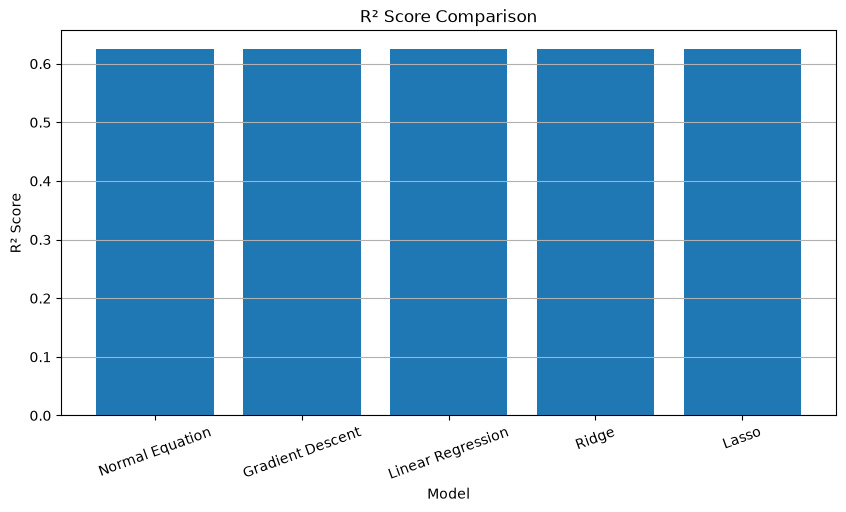

In [43]:
#R^2 compare:
r2_values = [
    r2_normal,
    r2_gd,
    r2_sklearn,
    r2_ridge,
    r2_lasso
]

plt.figure(figsize=(10, 5))

plt.bar(
    models,
    r2_values
)

plt.xlabel("Model")

plt.ylabel("R² Score")

plt.title("R² Score Comparison")

plt.xticks(rotation=20)

plt.grid(axis="y")

plt.show()

In [44]:
#final:
print("FINAL MODEL COMPARISON")
print("======================")

print(
    f"Normal Equation       -> "
    f"MSE: {mse_normal:.4f}, "
    f"R²: {r2_normal:.4f}"
)

print(
    f"Gradient Descent      -> "
    f"MSE: {mse_gd:.4f}, "
    f"R²: {r2_gd:.4f}"
)

print(
    f"Linear Regression     -> "
    f"MSE: {mse_sklearn:.4f}, "
    f"R²: {r2_sklearn:.4f}"
)

print(
    f"Ridge Regression      -> "
    f"MSE: {mse_ridge:.4f}, "
    f"R²: {r2_ridge:.4f}"
)

print(
    f"Lasso Regression      -> "
    f"MSE: {mse_lasso:.4f}, "
    f"R²: {r2_lasso:.4f}"
)

FINAL MODEL COMPARISON
Normal Equation       -> MSE: 4908476721.1566, R²: 0.6254
Gradient Descent      -> MSE: 4912600336.8855, R²: 0.6251
Linear Regression     -> MSE: 4908476721.1566, R²: 0.6254
Ridge Regression      -> MSE: 4908043808.2549, R²: 0.6255
Lasso Regression      -> MSE: 4908475937.1449, R²: 0.6254
